In [32]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [33]:
nifty50 = pd.read_csv('../data/nifty50_data.csv', index_col=0, parse_dates=True)

C:\Users\naman\AppData\Local\Temp\ipykernel_26628\3054469281.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nifty50 = pd.read_csv('../data/nifty50_data.csv', index_col=0, parse_dates=True)


In [34]:
nifty50.head()

,Date,Close,High,Low,Open,Volume
0,2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
1,2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2,2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
3,2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
4,2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


In [35]:
print(f"Nifty50 shape: {nifty50.shape}")

Nifty50 shape: (2988, 6)


In [36]:
nifty50["log_return"] = np.log(nifty50["Close"] / nifty50["Close"].shift(1))

In [37]:
nifty50["rolling_volatility"] = nifty50["log_return"].rolling(window=30).std() * np.sqrt(252)

In [38]:
nifty50["hl_spread"] = nifty50["High"] - nifty50["Low"]

In [39]:
nifty50["volume_change"] = nifty50["Volume"].pct_change()

In [40]:
nifty50.isnull().sum()

Date                   0
Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
log_return             1
rolling_volatility    30
hl_spread              0
volume_change          4
dtype: int64

In [41]:
nifty50["log_return"]= nifty50["log_return"].bfill()
nifty50["rolling_volatility"] = nifty50["rolling_volatility"].bfill()
nifty50["volume_change"] = nifty50["volume_change"].bfill()

In [42]:
nifty50.to_csv('../data/nifty50_enhanced.csv', index=False)

## Nifty50 Stationary Test

In [43]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(nifty50["log_return"].dropna())

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("Result        : Stationary")
else:
    print("Result        : Non-Stationary")

ADF Statistic : -15.233549892228428
p-value       : 5.280664218630186e-28
Result        : Stationary


## AAPL ACF OF RETURNS

<Figure size 1000x500 with 0 Axes>

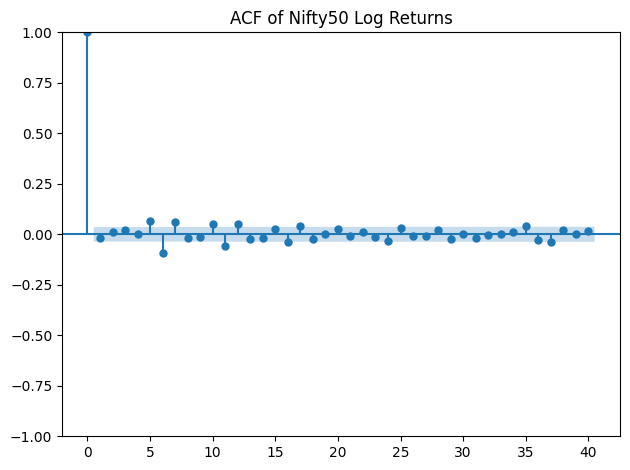

In [50]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    nifty50["log_return"].dropna(),
    lags=40
)

plt.title("ACF of Nifty50 Log Returns")

plt.tight_layout()
plt.show()

## Nifty 50 PACF OF RETURNS

<Figure size 1000x500 with 0 Axes>

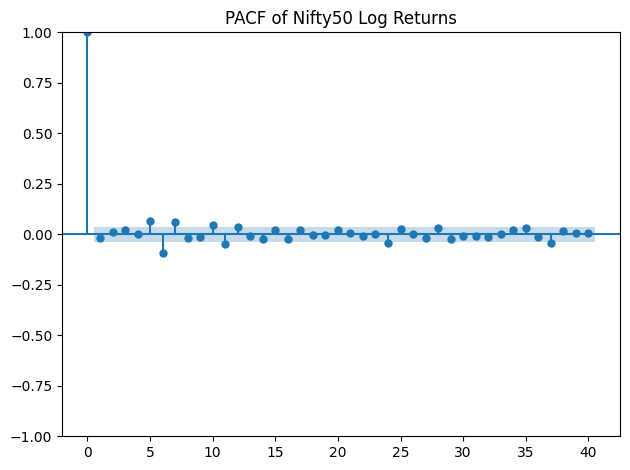

In [44]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plot_pacf(
    nifty50["log_return"].dropna(),
    lags=40
)

plt.title("PACF of Nifty50 Log Returns")

plt.tight_layout()
plt.show()

## Nifty 50 ARCH LM TEST

In [45]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(nifty50["log_return"].dropna())

print("LM Statistic :", arch_test[0])
print("p-value      :", arch_test[1])

if arch_test[1] < 0.05:
    print("ARCH Effects Present")
else:
    print("No ARCH Effects")

LM Statistic : 768.588002895935
p-value      : 1.1646920337931347e-158
ARCH Effects Present


## Nifty 50 GARCH(1,1) MODEL

In [46]:
from arch import arch_model

# Scale returns for numerical stability
returns = nifty50["log_return"].dropna() * 100

# Build model
garch_model = arch_model(
    returns,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

# Fit model
garch_fit = garch_model.fit()

# Summary
print(garch_fit.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 16683.52462391827
Iteration:      2,   Func. Count:     13,   Neg. LLF: 4537.720212890178
Iteration:      3,   Func. Count:     20,   Neg. LLF: 6588.03691571755
Iteration:      4,   Func. Count:     25,   Neg. LLF: 3815.2458895314394
Iteration:      5,   Func. Count:     30,   Neg. LLF: 3815.062473865023
Iteration:      6,   Func. Count:     34,   Neg. LLF: 3815.047804262014
Iteration:      7,   Func. Count:     38,   Neg. LLF: 3815.047755225156
Iteration:      8,   Func. Count:     41,   Neg. LLF: 3815.0477552244706
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3815.047755225156
            Iterations: 8
            Function evaluations: 41
            Gradient evaluations: 8
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:   

## Nifty 50 CONDITIONAL VOLATILITY PLOT

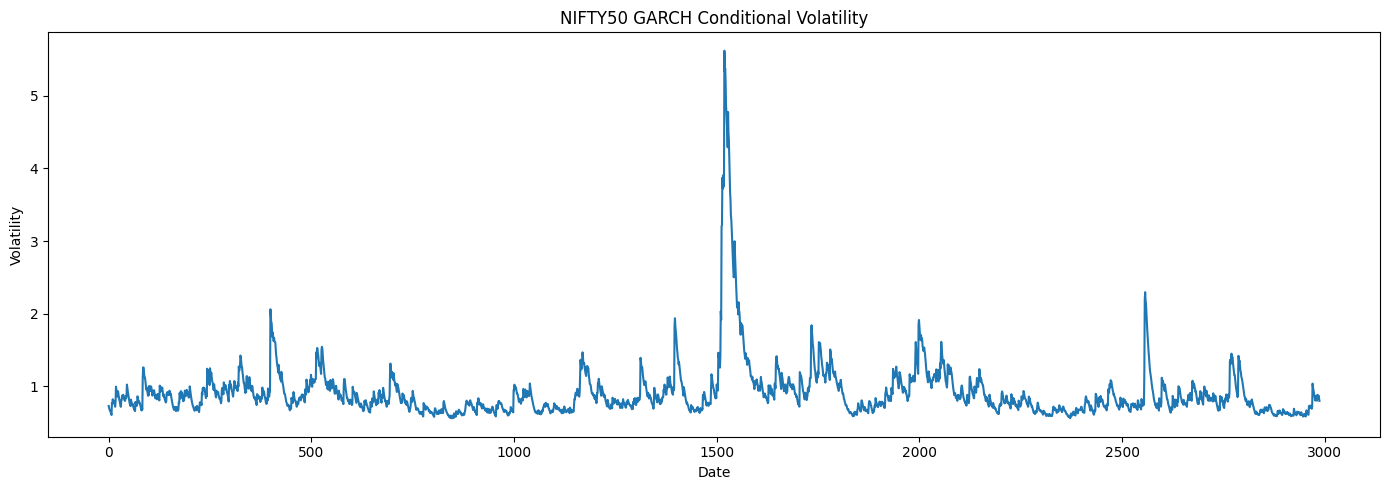

In [47]:
plt.figure(figsize=(14,5))

plt.plot(
    nifty50.index[-len(garch_fit.conditional_volatility):],
    garch_fit.conditional_volatility
)

plt.title("NIFTY50 GARCH Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.tight_layout()
plt.show()

Nifty 50 ACTUAL RETURNS vs GARCH VOLATILITY

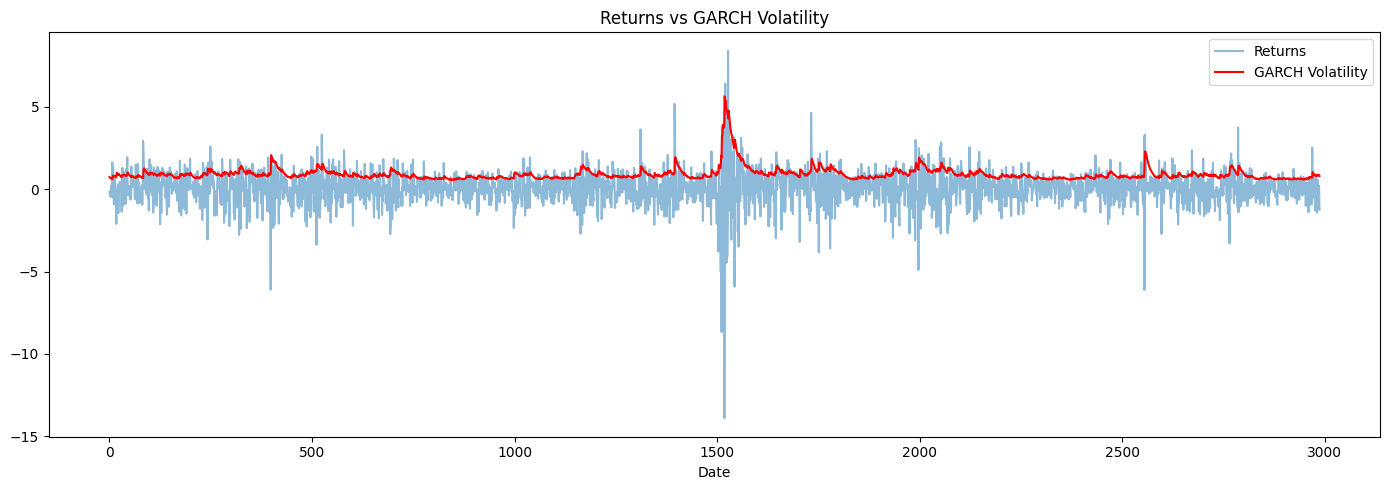

In [48]:
plt.figure(figsize=(14,5))

plt.plot(
    nifty50.index[-len(returns):],
    returns,
    alpha=0.5,
    label="Returns"
)

plt.plot(
    nifty50.index[-len(garch_fit.conditional_volatility):],
    garch_fit.conditional_volatility,
    color='red',
    label="GARCH Volatility"
)

plt.title("Returns vs GARCH Volatility")
plt.xlabel("Date")

plt.legend()

plt.tight_layout()
plt.show()

## VOLATILITY FORECAST

In [49]:
forecast = garch_fit.forecast(horizon=5)

print("Next 5 Day Volatility Forecast:")
print(forecast.variance.iloc[-1])

Next 5 Day Volatility Forecast:
h.1    0.735341
h.2    0.740998
h.3    0.746510
h.4    0.751879
h.5    0.757109
Name: 2987, dtype: float64
